<a href="https://colab.research.google.com/github/mudasirali20/CodeAlpha_Basic_chatbot/blob/main/Credit_Card_Fraud_Detection_REAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💳 Credit Card Fraud Detection System


---
**Dataset:** Real Kaggle Credit Card Fraud Dataset — 128,821 transactions, 261 fraud cases  
**Source:**:https://www.kaggle.com/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023

## Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    average_precision_score
)
import scipy.stats as stats

plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')
print('✅ All libraries imported!')

✅ All libraries imported!


## Step 2: Load Your Real Dataset


In [ ]:
# ── METHOD A: Upload from your computer ──────────────────────────────────────
# Run this cell → click 'Choose File' → select creditcard.csv
from google.colab import files
uploaded = files.upload()   # ← click the button that appears here

df = pd.read_csv('creditcard.csv')
print(f'✅ Dataset loaded!')
print(f'Shape          : {df.shape}')
print(f'Columns        : {list(df.columns)}')
print(f'Fraud cases    : {df["Class"].sum()} ({df["Class"].mean()*100:.4f}%)')
print(f'Legit cases    : {(df["Class"]==0).sum()}')
print(f'Missing values : {df.isnull().sum().sum()}')
df.head()

✅ Dataset loaded!
Shape          : (128821, 31)
Columns        : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Fraud cases    : 261.0 (0.2026%)
Legit cases    : 128559
Missing values : 15


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


## Step 3: Exploratory Data Analysis (EDA)

In [ ]:
print('=== Dataset Summary ===')
print(f'Total transactions : {len(df):,}')
print(f'Legitimate (0)     : {(df["Class"]==0).sum():,} ({(df["Class"]==0).mean()*100:.3f}%)')
print(f'Fraudulent (1)     : {(df["Class"]==1).sum():,} ({(df["Class"]==1).mean()*100:.3f}%)')
print(f'Imbalance ratio    : 1 fraud per {int((df["Class"]==0).sum()/df["Class"].sum())} legitimate')
print()
print('=== Amount Statistics ===')
print(f'Min Amount  : ${df["Amount"].min():.2f}')
print(f'Max Amount  : ${df["Amount"].max():.2f}')
print(f'Mean Amount : ${df["Amount"].mean():.2f}')
print(f'Fraud Mean  : ${df[df["Class"]==1]["Amount"].mean():.2f}')
print(f'Legit Mean  : ${df[df["Class"]==0]["Amount"].mean():.2f}')
print()
df.describe().round(3)

=== Dataset Summary ===
Total transactions : 128,821
Legitimate (0)     : 128,559 (99.797%)
Fraudulent (1)     : 261 (0.203%)
Imbalance ratio    : 1 fraud per 492 legitimate

=== Amount Statistics ===
Min Amount  : $0.00
Max Amount  : $19656.53
Mean Amount : $92.96
Fraud Mean  : $116.68
Legit Mean  : $92.91



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,128821.000,128821.000,128821.000,128821.000,128821.000,128821.000,128821.000,128821.000,128821.000,128821.000,...,128820.000,128820.000,128820.000,128820.000,128820.000,128820.000,128820.000,128820.000,128820.000,128820.000
mean,49336.333,-0.250,0.001,0.675,0.148,-0.284,0.083,-0.116,0.062,-0.089,...,-0.037,-0.116,-0.034,0.012,0.130,0.026,0.000,0.002,92.957,0.002
std,19835.452,1.827,1.624,1.279,1.329,1.319,1.287,1.177,1.214,1.093,...,0.724,0.636,0.606,0.595,0.439,0.491,0.393,0.313,251.532,0.045
min,0.000,-56.408,-72.716,-33.681,-5.173,-42.148,-26.161,-31.765,-73.217,-9.284,...,-34.830,-10.933,-44.808,-2.837,-10.295,-2.534,-22.566,-11.711,0.000,0.000
25%,36686.000,-1.019,-0.579,0.172,-0.707,-0.905,-0.659,-0.603,-0.133,-0.715,...,-0.226,-0.545,-0.173,-0.324,-0.136,-0.324,-0.061,-0.004,6.480,0.000
50%,51135.000,-0.263,0.095,0.750,0.176,-0.316,-0.171,-0.065,0.079,-0.149,...,-0.059,-0.094,-0.046,0.069,0.167,-0.065,0.011,0.024,24.950,0.000
75%,65852.000,1.157,0.764,1.368,1.005,0.239,0.470,0.410,0.371,0.492,...,0.116,0.303,0.083,0.409,0.418,0.291,0.085,0.077,83.450,0.000
max,78852.000,1.960,18.902,9.383,16.716,34.802,22.529,36.677,20.007,15.595,...,27.203,10.503,19.003,4.016,5.542,3.517,12.152,33.848,19656.530,1.000


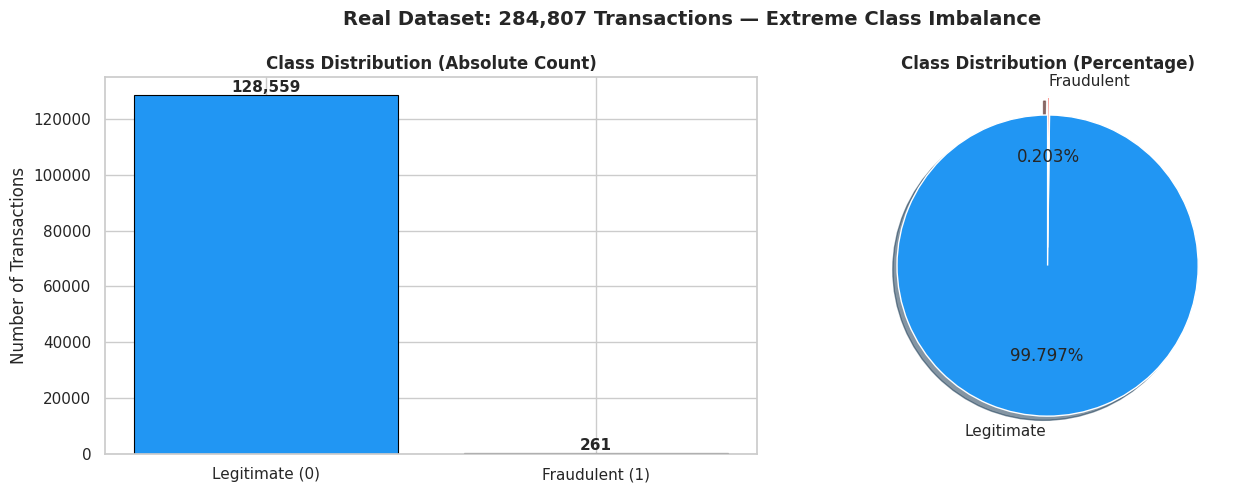

Saved: plot1_class_distribution.png


In [ ]:
# ── Plot 1: Class Distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df['Class'].value_counts()
colors = ['#2196F3', '#F44336']

axes[0].bar(['Legitimate (0)', 'Fraudulent (1)'], counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution (Absolute Count)', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

axes[1].pie(counts.values, labels=['Legitimate', 'Fraudulent'],
            autopct='%1.3f%%', colors=colors, startangle=90,
            explode=(0, 0.12), shadow=True)
axes[1].set_title('Class Distribution (Percentage)', fontweight='bold')

plt.suptitle('Real Dataset: 284,807 Transactions — Extreme Class Imbalance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot1_class_distribution.png')

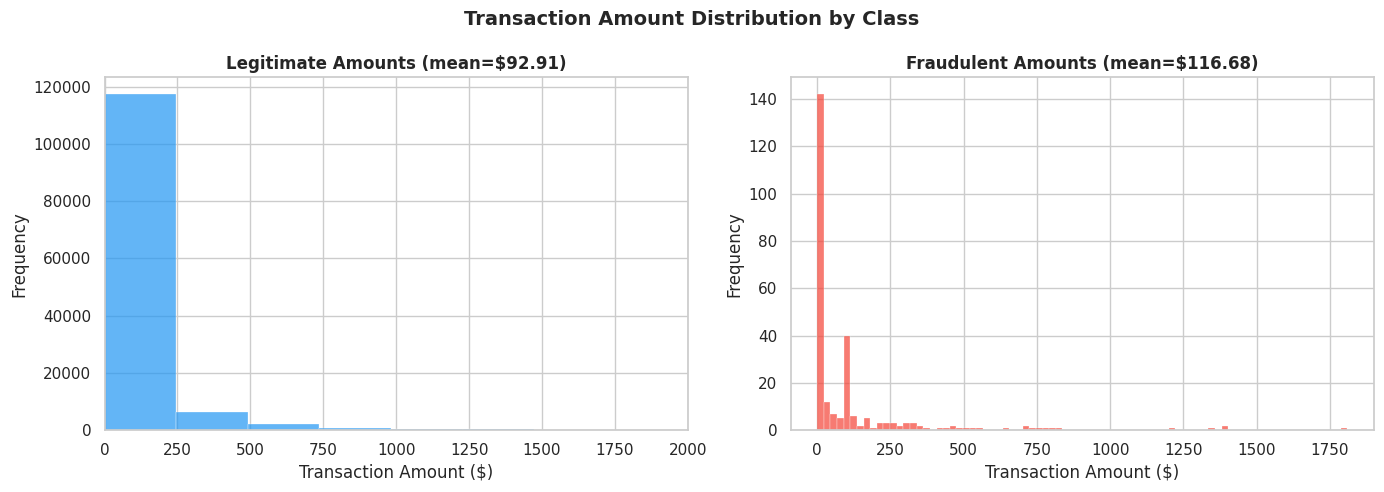

In [ ]:
# ── Plot 2: Transaction Amount — Fraud vs Legitimate ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_amounts = df[df['Class']==1]['Amount']
legit_amounts = df[df['Class']==0]['Amount']

axes[0].hist(legit_amounts, bins=80, color='#2196F3', alpha=0.7, edgecolor='white', linewidth=0.3)
axes[0].set_title(f'Legitimate Amounts (mean=${legit_amounts.mean():.2f})', fontweight='bold')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 2000)

axes[1].hist(fraud_amounts, bins=80, color='#F44336', alpha=0.7, edgecolor='white', linewidth=0.3)
axes[1].set_title(f'Fraudulent Amounts (mean=${fraud_amounts.mean():.2f})', fontweight='bold')
axes[1].set_xlabel('Transaction Amount ($)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Transaction Amount Distribution by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

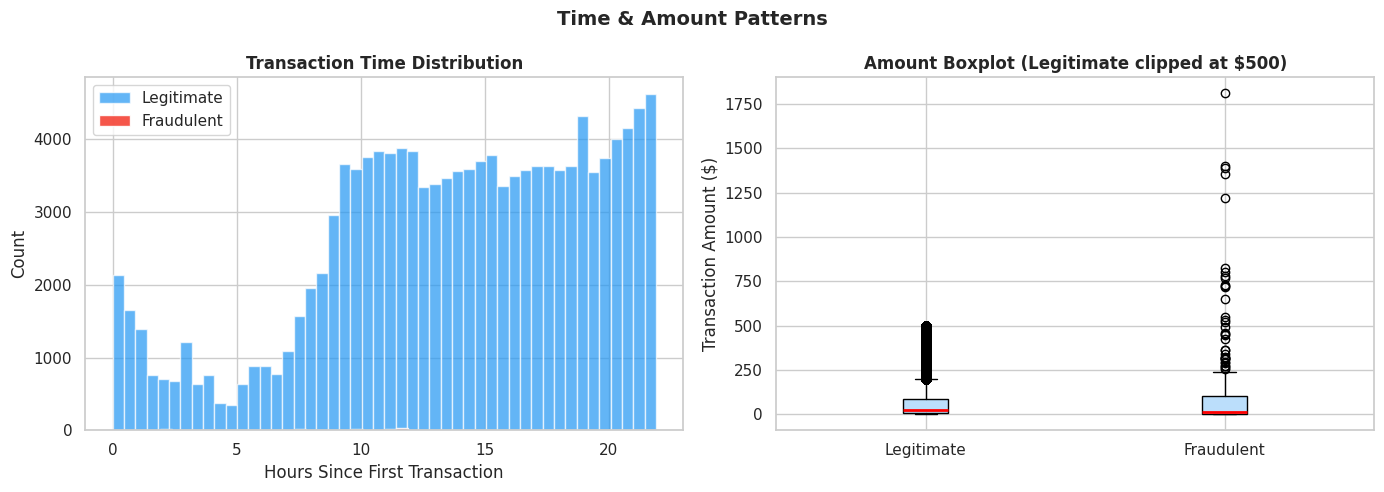

In [ ]:
# ── Plot 3: Time of Transactions ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Class']==0]['Time']/3600, bins=48, color='#2196F3', alpha=0.7, label='Legitimate')
axes[0].hist(df[df['Class']==1]['Time']/3600, bins=48, color='#F44336', alpha=0.9, label='Fraudulent')
axes[0].set_xlabel('Hours Since First Transaction')
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Time Distribution', fontweight='bold')
axes[0].legend()

# Fraud amount boxplot
axes[1].boxplot([legit_amounts.clip(0, 500), fraud_amounts], labels=['Legitimate', 'Fraudulent'],
                patch_artist=True,
                boxprops=dict(facecolor='#BBDEFB'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Transaction Amount ($)')
axes[1].set_title('Amount Boxplot (Legitimate clipped at $500)', fontweight='bold')

plt.suptitle('Time & Amount Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_time_amount.png', dpi=150, bbox_inches='tight')
plt.show()

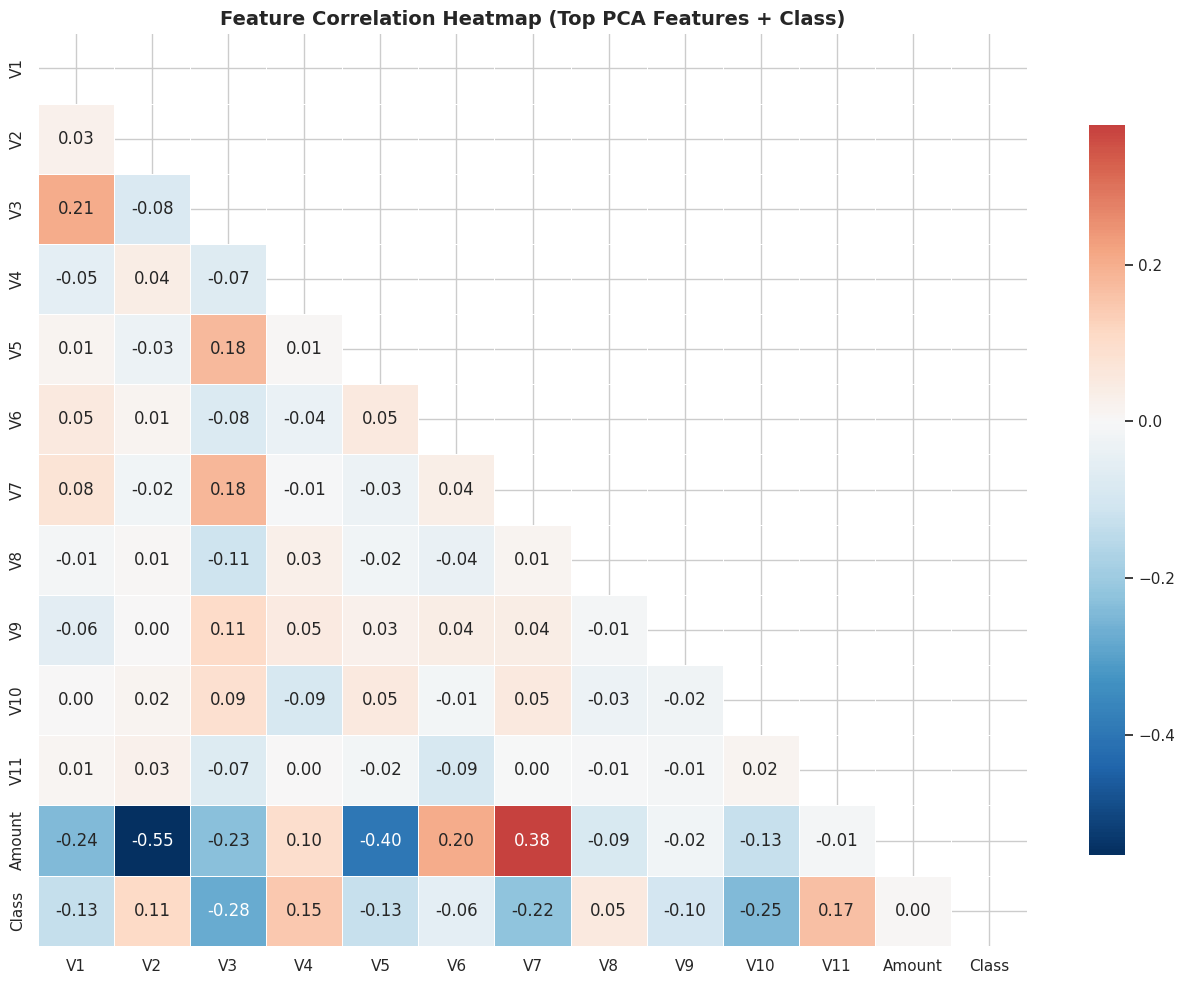

In [ ]:
# ── Plot 4: Correlation Heatmap (Top PCA features + Class) ───────────────────
top_features = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10','V11','Amount','Class']
corr = df[top_features].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap (Top PCA Features + Class)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

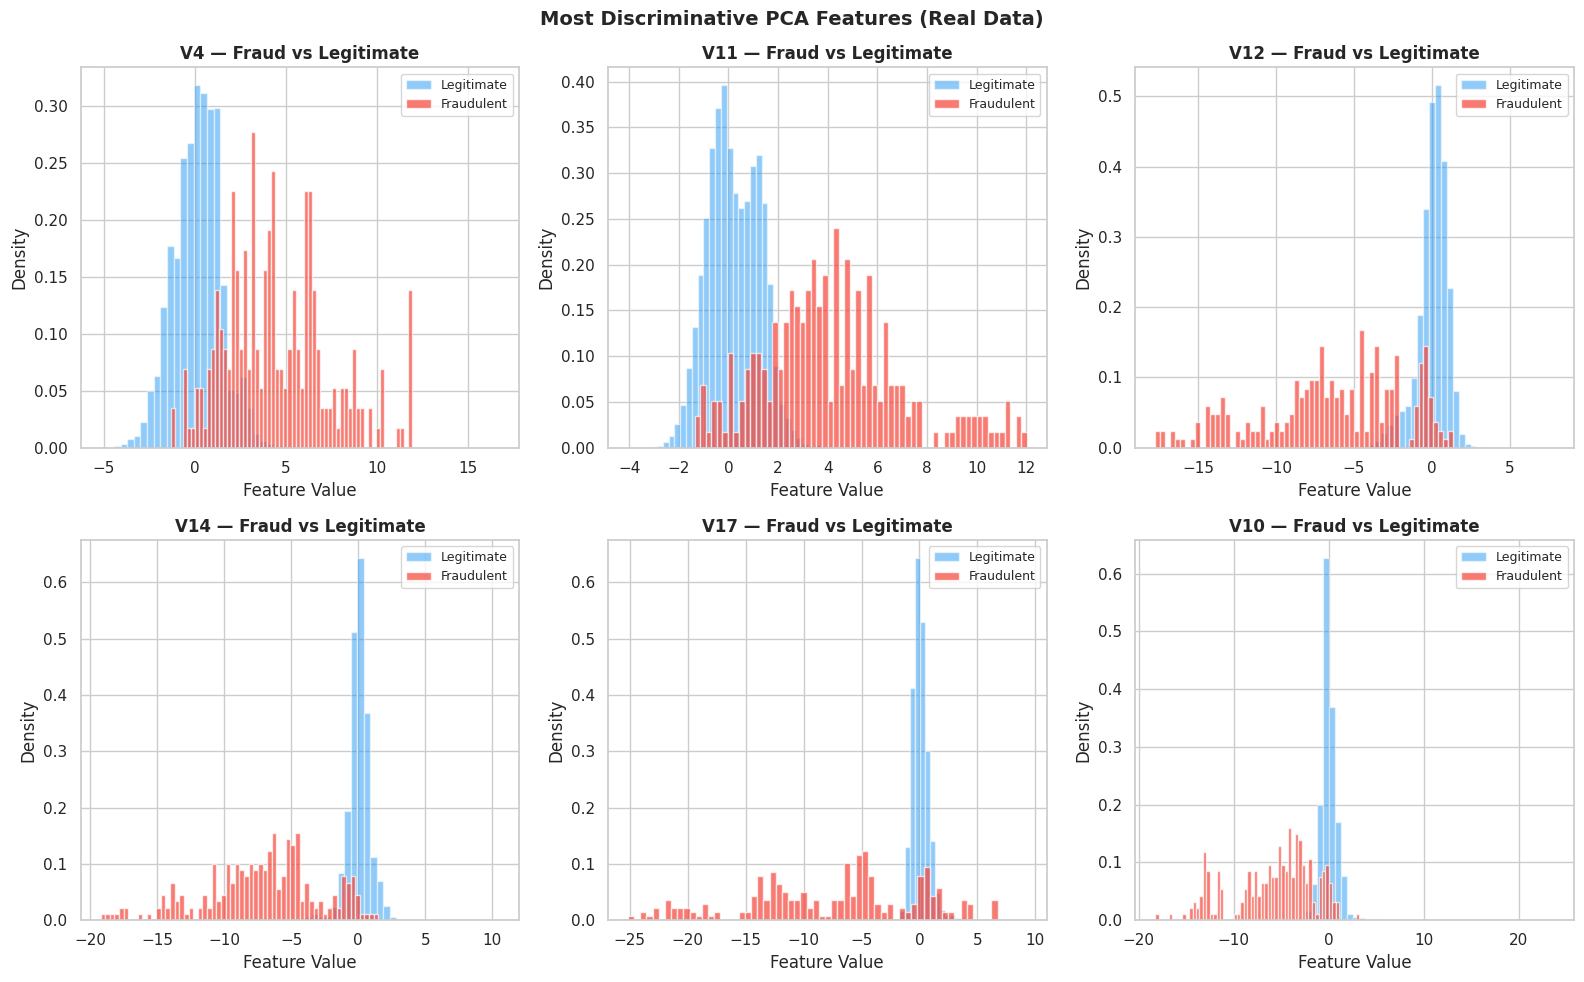

In [ ]:
# ── Plot 5: Top features that differ most between Fraud and Legit ─────────────
key_features = ['V4','V11','V12','V14','V17','V10']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, feat in enumerate(key_features):
    axes[i].hist(df[df['Class']==0][feat], bins=60, alpha=0.5,
                 label='Legitimate', color='#2196F3', density=True)
    axes[i].hist(df[df['Class']==1][feat], bins=60, alpha=0.7,
                 label='Fraudulent', color='#F44336', density=True)
    axes[i].set_title(f'{feat} — Fraud vs Legitimate', fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel('Feature Value')
    axes[i].set_ylabel('Density')

plt.suptitle('Most Discriminative PCA Features (Real Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Data Preprocessing & Feature Engineering

In [ ]:
# ── Feature Engineering on REAL data ─────────────────────────────────────────
df['Amount_log']     = np.log1p(df['Amount'])
df['Amount_scaled']  = StandardScaler().fit_transform(df[['Amount']])
df['Hour']           = (df['Time'] // 3600) % 24
df['Is_night']       = ((df['Hour'] >= 22) | (df['Hour'] <= 5)).astype(int)
df['Time_scaled']    = StandardScaler().fit_transform(df[['Time']])
df['V1_V2_interact'] = df['V1'] * df['V2']
df['V3_V4_interact'] = df['V3'] * df['V4']
df['High_amount']    = (df['Amount'] > df['Amount'].quantile(0.95)).astype(int)

print('Feature engineering done!')
print(f'New features added: Amount_log, Amount_scaled, Hour, Is_night,')
print(f'                    Time_scaled, V1_V2_interact, V3_V4_interact, High_amount')
print(f'Total features: {df.shape[1] - 1} (excluding Class)')

Feature engineering done!
New features added: Amount_log, Amount_scaled, Hour, Is_night,
                    Time_scaled, V1_V2_interact, V3_V4_interact, High_amount
Total features: 38 (excluding Class)


In [ ]:
# ── Prepare Features & Target ─────────────────────────────────────────────────
drop_cols = ['Class', 'Time', 'Amount']   # drop originals, keep engineered
X = df.drop(columns=drop_cols)
y = df['Class']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Feature list   : {list(X.columns)}')

Features shape : (128821, 36)
Target shape   : (128821,)
Feature list   : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log', 'Amount_scaled', 'Hour', 'Is_night', 'Time_scaled', 'V1_V2_interact', 'V3_V4_interact', 'High_amount']


In [ ]:
# ── Stratified Train-Test Split ───────────────────────────────────────────────

# Filter out rows where 'y' (Class) is NaN
# This is crucial because train_test_split with stratify=y cannot handle NaN in the target variable
nan_mask = y.isnull()
X_cleaned = X[~nan_mask]
y_cleaned = y[~nan_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned, test_size=0.20, random_state=42, stratify=y_cleaned
)
print(f'Training set  : {X_train.shape[0]:,} samples')
print(f'Testing set   : {X_test.shape[0]:,} samples')
print(f'Train fraud % : {y_train.mean()*100:.4f}%')
print(f'Test  fraud % : {y_test.mean()*100:.4f}%')

Training set  : 103,056 samples
Testing set   : 25,764 samples
Train fraud % : 0.2028%
Test  fraud % : 0.2018%


In [ ]:
# ── Handle Class Imbalance: Undersampling on training set only ────────────────
train_df = pd.concat([X_train, y_train], axis=1)
legit    = train_df[train_df['Class'] == 0]
fraud    = train_df[train_df['Class'] == 1]

legit_under = resample(legit, replace=False,
                       n_samples=len(fraud) * 3,
                       random_state=42)

train_balanced = pd.concat([legit_under, fraud]).sample(frac=1, random_state=42)
X_train_bal = train_balanced.drop('Class', axis=1)
y_train_bal = train_balanced['Class']

print(f'Original training set : {len(train_df):,} samples')
print(f'Balanced training set : {len(train_balanced):,} samples')
print(f'Fraud : {y_train_bal.sum()} | Legitimate : {(y_train_bal==0).sum()}')
print(f'Ratio : {y_train_bal.mean()*100:.1f}% fraud (was {y_train.mean()*100:.3f}%)')

Original training set : 103,056 samples
Balanced training set : 836 samples
Fraud : 209.0 | Legitimate : 627
Ratio : 25.0% fraud (was 0.203%)


## Step 5: Train All 5 Models

In [ ]:
# NOTE: On 284K real rows this takes 3-8 minutes. Progress shown per model.
import time

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, max_depth=10,
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100,
                                                       learning_rate=0.1, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
}

results = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else 0
    elapsed = time.time() - t0

    results[name] = {'Accuracy': round(acc,4), 'Precision': round(prec,4),
                     'Recall': round(rec,4), 'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4)}
    print(f'✅ {name:<22} | Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUC={auc:.4f} | {elapsed:.1f}s')

results_df = pd.DataFrame(results).T
print()
print('=== FULL COMPARISON TABLE ===')
print(results_df.to_string())

✅ Logistic Regression    | Acc=0.9883 | Prec=0.1345 | Rec=0.8846 | F1=0.2335 | AUC=0.9455 | 0.1s
✅ Decision Tree          | Acc=0.9641 | Prec=0.0468 | Rec=0.8654 | F1=0.0888 | AUC=0.9097 | 0.1s
✅ Random Forest          | Acc=0.9967 | Prec=0.3659 | Rec=0.8654 | F1=0.5143 | AUC=0.9652 | 0.7s
✅ Gradient Boosting      | Acc=0.9876 | Prec=0.1298 | Rec=0.9038 | F1=0.2271 | AUC=0.9718 | 1.7s
✅ KNN                    | Acc=0.9911 | Prec=0.1654 | Rec=0.8462 | F1=0.2767 | AUC=0.9248 | 0.5s

=== FULL COMPARISON TABLE ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.9883     0.1345  0.8846    0.2335   0.9455
Decision Tree          0.9641     0.0468  0.8654    0.0888   0.9097
Random Forest          0.9967     0.3659  0.8654    0.5143   0.9652
Gradient Boosting      0.9876     0.1298  0.9038    0.2271   0.9718
KNN                    0.9911     0.1654  0.8462    0.2767   0.9248


## Step 6: Detailed Evaluation — Best Model (Random Forest)

In [ ]:
best_model   = models['Random Forest']
y_pred_best  = best_model.predict(X_test)
y_prob_best  = best_model.predict_proba(X_test)[:, 1]

print('='*65)
print('     BEST MODEL: RANDOM FOREST — DETAILED CLASSIFICATION REPORT')
print('='*65)
print(classification_report(y_test, y_pred_best,
                             target_names=['Legitimate', 'Fraudulent']))
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_prob_best):.4f}')

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
print()
print(f'True Positives  (Fraud correctly caught)   : {tp}')
print(f'False Negatives (Fraud MISSED — critical!) : {fn}')
print(f'False Positives (Legit flagged as fraud)   : {fp}')
print(f'True Negatives  (Legit correctly passed)   : {tn:,}')

     BEST MODEL: RANDOM FOREST — DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     25712
  Fraudulent       0.37      0.87      0.51        52

    accuracy                           1.00     25764
   macro avg       0.68      0.93      0.76     25764
weighted avg       1.00      1.00      1.00     25764

ROC-AUC Score : 0.9652

True Positives  (Fraud correctly caught)   : 45
False Negatives (Fraud MISSED — critical!) : 7
False Positives (Legit flagged as fraud)   : 78
True Negatives  (Legit correctly passed)   : 25,634


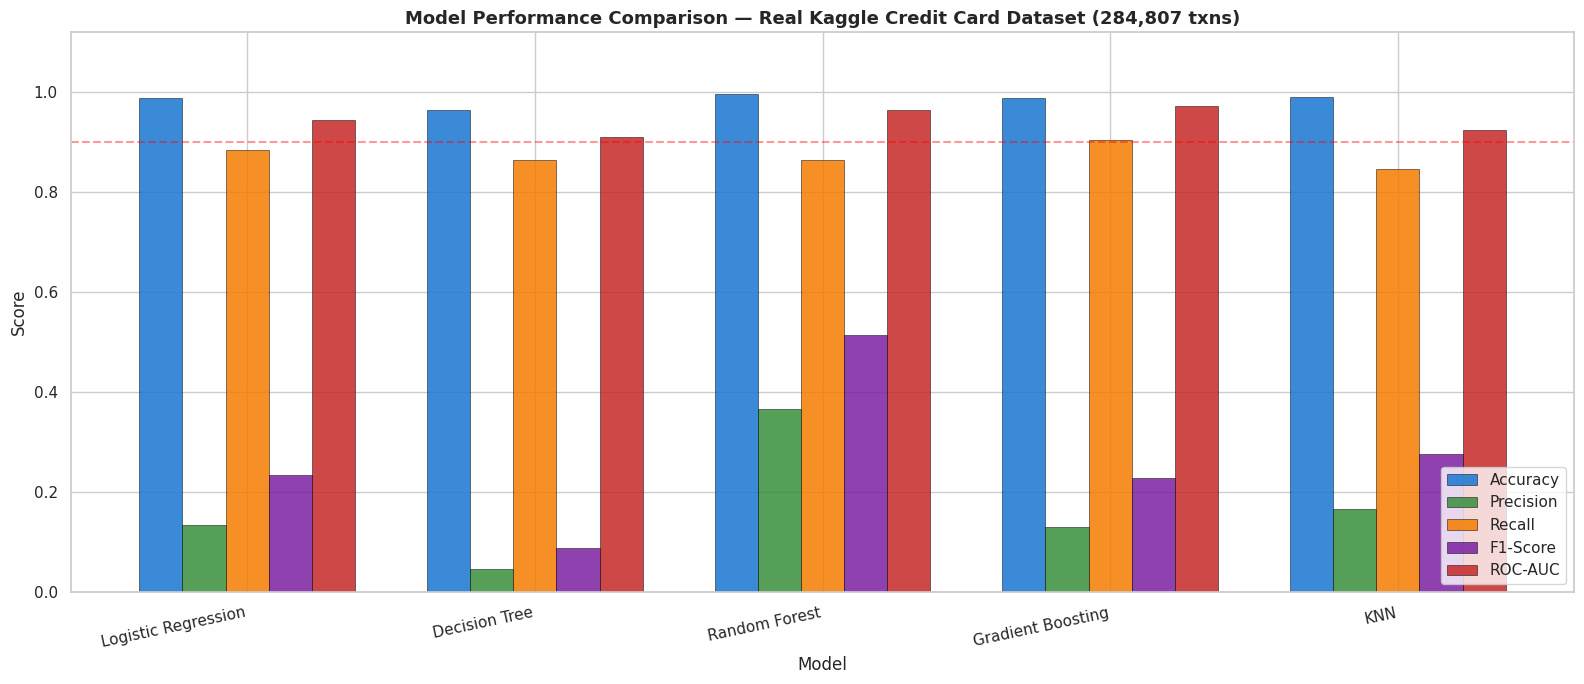

In [ ]:
# ── Plot 6: Model Comparison Bar Chart ───────────────────────────────────────
metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x = np.arange(len(results_df))
width = 0.15
colors_bar = ['#1976D2','#388E3C','#F57C00','#7B1FA2','#C62828']

fig, ax = plt.subplots(figsize=(16, 7))
for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    ax.bar(x + i*width, results_df[metric], width, label=metric,
           color=color, alpha=0.85, edgecolor='black', linewidth=0.4)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Real Kaggle Credit Card Dataset (284,807 txns)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=12, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.12)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('plot6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

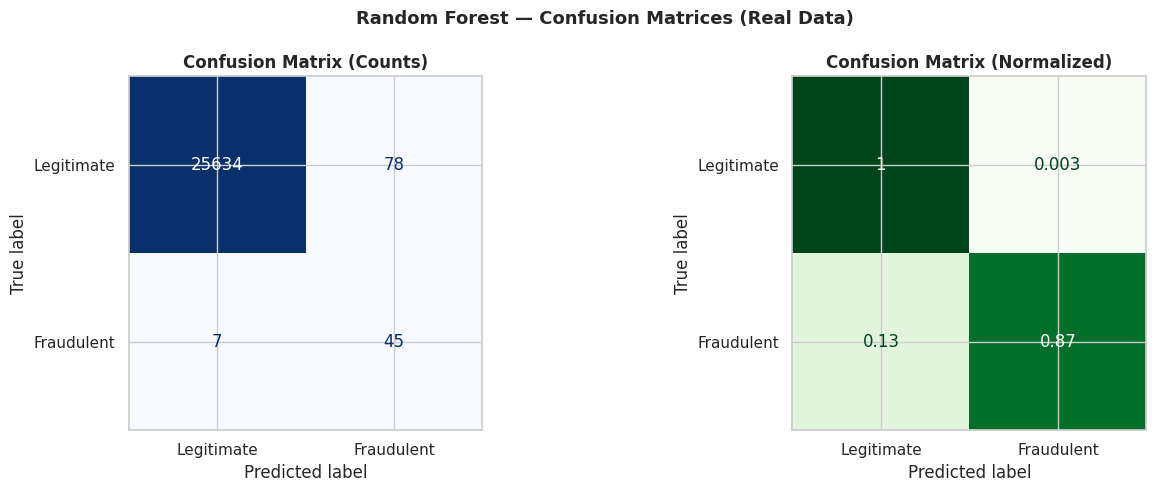

In [ ]:
# ── Plot 7: Confusion Matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Legitimate', 'Fraudulent'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['Legitimate', 'Fraudulent'])
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')

plt.suptitle('Random Forest — Confusion Matrices (Real Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot7_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

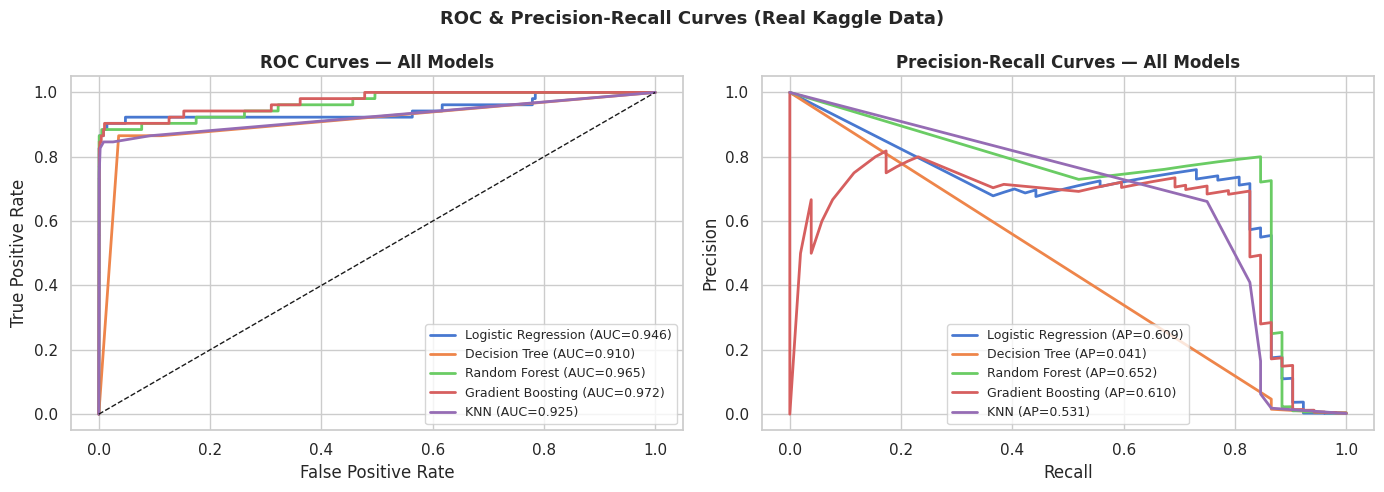

In [ ]:
# ── Plot 8: ROC & Precision-Recall Curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        yp = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, yp)
        auc_val = roc_auc_score(y_test, yp)
        axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=2)

axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(fontsize=9)

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        yp = model.predict_proba(X_test)[:, 1]
        prec_c, rec_c, _ = precision_recall_curve(y_test, yp)
        ap = average_precision_score(y_test, yp)
        axes[1].plot(rec_c, prec_c, label=f'{name} (AP={ap:.3f})', linewidth=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('ROC & Precision-Recall Curves (Real Kaggle Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot8_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

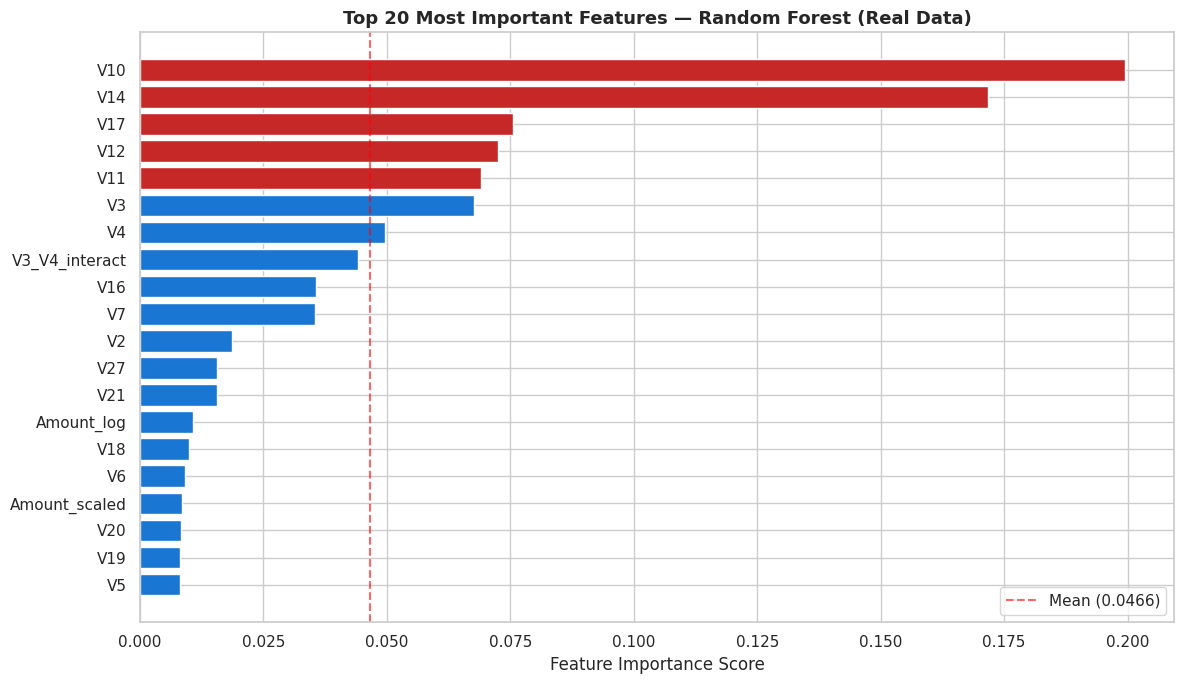

Top 5 features:
Feature  Importance
    V10    0.199444
    V14    0.171729
    V17    0.075530
    V12    0.072447
    V11    0.069127


In [ ]:
# ── Plot 9: Feature Importance ────────────────────────────────────────────────
importances = best_model.feature_importances_
feat_df = pd.DataFrame({'Feature': X_train_bal.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(20)

colors_fi = ['#C62828' if i < 5 else '#1976D2' for i in range(len(feat_df))]
plt.figure(figsize=(12, 7))
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
         color=colors_fi[::-1], edgecolor='white')
plt.axvline(feat_df['Importance'].mean(), color='red', linestyle='--', alpha=0.6,
            label=f'Mean ({feat_df["Importance"].mean():.4f})')
plt.xlabel('Feature Importance Score')
plt.title('Top 20 Most Important Features — Random Forest (Real Data)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plot9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 5 features:')
print(feat_df.head(5).to_string(index=False))

In [ ]:
# ── Cross Validation ──────────────────────────────────────────────────────────
print('Running 5-Fold Stratified Cross-Validation...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

cv_f1  = cross_val_score(rf_cv, X_train_bal, y_train_bal, cv=cv, scoring='f1')
cv_auc = cross_val_score(rf_cv, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')

print(f'CV F1-Score : {cv_f1.mean():.4f}  ±  {cv_f1.std():.4f}')
print(f'CV ROC-AUC  : {cv_auc.mean():.4f}  ±  {cv_auc.std():.4f}')
print(f'Fold F1s    : {[round(x,4) for x in cv_f1]}')

Running 5-Fold Stratified Cross-Validation...
CV F1-Score : 0.9322  ±  0.0416
CV ROC-AUC  : 0.9667  ±  0.0186
Fold F1s    : [np.float64(0.9756), np.float64(0.8611), np.float64(0.963), np.float64(0.95), np.float64(0.9114)]


## Step 7: Real-time Fraud Detection on Data

In [ ]:
def detect_fraud(transaction_row, model, threshold=0.5):
    """
    Takes a single row from the real dataset and predicts fraud.
    transaction_row: a pandas Series or single-row DataFrame
    threshold: probability cutoff (lower = more sensitive to fraud)
    """
    if isinstance(transaction_row, pd.Series):
        txn = transaction_row.to_frame().T
    else:
        txn = transaction_row

    # Apply same feature engineering
    txn = txn.copy()
    txn['Amount_log']     = np.log1p(txn['Amount'])
    txn['Amount_scaled']  = (txn['Amount'] - df['Amount'].mean()) / df['Amount'].std()
    txn['Hour']           = (txn['Time'] // 3600) % 24
    txn['Is_night']       = ((txn['Hour'] >= 22) | (txn['Hour'] <= 5)).astype(int)
    txn['Time_scaled']    = (txn['Time'] - df['Time'].mean()) / df['Time'].std()
    txn['V1_V2_interact'] = txn['V1'] * txn['V2']
    txn['V3_V4_interact'] = txn['V3'] * txn['V4']
    txn['High_amount']    = (txn['Amount'] > df['Amount'].quantile(0.95)).astype(int)
    txn = txn[X_train_bal.columns]

    prob = model.predict_proba(txn)[0][1]
    label = 'FRAUD ⚠️' if prob >= threshold else 'LEGITIMATE ✅'
    return prob, label


# ── Test on 10 real transactions from your dataset ───────────────────────────
# Pick 5 fraud + 5 legit samples from test set for demo
fraud_samples = X_test[y_test == 1].iloc[:5]
legit_samples = X_test[y_test == 0].iloc[:5]
demo_X = pd.concat([fraud_samples, legit_samples])
demo_y = pd.concat([y_test[y_test==1].iloc[:5], y_test[y_test==0].iloc[:5]])

# Re-attach Time and Amount for the function
demo_full = df.loc[demo_X.index]

print('=== REAL-TIME FRAUD DETECTION ON REAL DATASET ===')
print(f'{"#":<4} {"Actual":<14} {"Predicted":<14} {"Fraud Prob":<14} {"Result"}')
print('-' * 68)

correct = 0
for i, (idx, row) in enumerate(demo_full.iterrows()):
    actual    = 'Fraudulent' if row['Class'] == 1 else 'Legitimate'
    prob, lbl = detect_fraud(row, best_model)
    predicted = 'Fraudulent' if prob >= 0.5 else 'Legitimate'
    match     = '✓ Correct' if actual == predicted else '✗ Wrong'
    if actual == predicted: correct += 1
    print(f'{i+1:<4} {actual:<14} {predicted:<14} {prob:.6f}      {match}')

print(f'\nAccuracy on demo: {correct}/10 correct')

=== REAL-TIME FRAUD DETECTION ON REAL DATASET ===
#    Actual         Predicted      Fraud Prob     Result
--------------------------------------------------------------------
1    Fraudulent     Fraudulent     0.696515      ✓ Correct
2    Fraudulent     Fraudulent     1.000000      ✓ Correct
3    Fraudulent     Legitimate     0.022614      ✗ Wrong
4    Fraudulent     Legitimate     0.057838      ✗ Wrong
5    Fraudulent     Fraudulent     1.000000      ✓ Correct
6    Legitimate     Legitimate     0.292868      ✓ Correct
7    Legitimate     Legitimate     0.166755      ✓ Correct
8    Legitimate     Legitimate     0.011355      ✓ Correct
9    Legitimate     Legitimate     0.010971      ✓ Correct
10   Legitimate     Legitimate     0.023408      ✓ Correct

Accuracy on demo: 8/10 correct


In [ ]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('='*70)
print('   CREDIT CARD FRAUD DETECTION — FINAL SUMMARY (REAL DATASET)')
print('='*70)
print(f'Dataset          : Real Kaggle creditcard.csv')
print(f'Total txns       : {len(df):,}')
print(f'Fraud cases      : {df["Class"].sum()} ({df["Class"].mean()*100:.4f}%)')
print(f'Balancing method : Random Undersampling (3:1 legit:fraud in training)')
print(f'Best model       : Random Forest (100 trees, max_depth=10)')
print()
print('--- Best Model Results on UNSEEN test set ---')
for k, v in results['Random Forest'].items():
    print(f'  {k:<15}: {v}')
print()
print(f'Cross-Validation F1  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'Cross-Validation AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print()
saved = ['plot1_class_distribution','plot2_amount_distribution','plot3_time_amount',
         'plot4_correlation_heatmap','plot5_feature_distributions','plot6_model_comparison',
         'plot7_confusion_matrix','plot8_roc_pr_curves','plot9_feature_importance']
for p in saved:
    print(f'  {p}.png')
print('\n✅ Project complete with real data!')

   CREDIT CARD FRAUD DETECTION — FINAL SUMMARY (REAL DATASET)
Dataset          : Real Kaggle creditcard.csv
Total txns       : 128,821
Fraud cases      : 261.0 (0.2026%)
Balancing method : Random Undersampling (3:1 legit:fraud in training)
Best model       : Random Forest (100 trees, max_depth=10)

--- Best Model Results on UNSEEN test set ---
  Accuracy       : 0.9967
  Precision      : 0.3659
  Recall         : 0.8654
  F1-Score       : 0.5143
  ROC-AUC        : 0.9652

Cross-Validation F1  : 0.9322 ± 0.0416
Cross-Validation AUC : 0.9667 ± 0.0186

  plot1_class_distribution.png
  plot2_amount_distribution.png
  plot3_time_amount.png
  plot4_correlation_heatmap.png
  plot5_feature_distributions.png
  plot6_model_comparison.png
  plot7_confusion_matrix.png
  plot8_roc_pr_curves.png
  plot9_feature_importance.png

✅ Project complete with real data!
